# RL 18 - Le secrétaire matroïdal : la conjecture mesurée, élément par élément

> **Bandeau preprint** : ce notebook s'appuie sur *The Matroid Secretary Conjecture is True*
> (Sahil Singla, arXiv 2609.14555, soumis le 13/09/2026 — **72 h avant l'écriture de ces
> lignes, non relu**). Nous ne démontrons RIEN : nous implémentons l'algorithme du papier
> (explicite, ~30 lignes) et nous **mesurons la garantie élément-par-élément** sur des
> matroïdes jouets. Même discipline d'honnêteté que rl_17 : mesurer, jamais re-prouver.

| | |
|---|---|
| **Module** | Décisions online sous incertitude — secrétaire et matroïdes |
| **Niveau** | Avancé (suite directe de rl_17 : analyse compétitive) |
| **Technologies** | Python stdlib pur (`random` + structures élémentaires) |
| **Durée estimée** | 35-40 min — instances jouets CPU, exécution complète < 2 min |

**Objectifs d'apprentissage** — à la fin de ce notebook, vous saurez :
- [ ] énoncer le problème du secrétaire (classique puis matroïdal) et sa garantie ;
- [ ] manipuler trois familles de matroïdes (uniforme, partition, graphique) via un simple
      **oracle d'indépendance** ;
- [ ] dérouler l'algorithme de Singla (échantillon `Bin(n, 1/2)`, configuration virtuelle,
      test du glouton des deux côtés) et comprendre pourquoi il ne connaît que **n** ;
- [ ] mesurer **P[acceptation de chaque élément de l'optimum]** et la comparer à la borne
      1/4 — y compris le prix de l'universalité face au 1/e du secrétaire classique ;
- [ ] utiliser une garantie théorique comme **test exécutable** de votre implémentation.

**Prérequis** : rl_17 (k-server, work function) — le fil « décisions online » ; aucune
mathématique au-delà d'un tri et d'un arbre couvrant.

**Navigation** : [README série](README.md) — compagnon thématique : rl_17 (k-server WFA)


## 1. Du problème des secrétaires au secrétaire matroïdal

Le **problème des secrétaires** (variante de l'arrêt optimal) : n candidats défilent dans un
ordre aléatoire, on ne peut pas revenir en arrière, et l'objectif est de maximiser la
probabilité d'embaucher **le meilleur**. La stratégie optimale observe une fraction 1/e des
candidats puis embauche le premier qui bat le maximum observé — probabilité de succès
**1/e ≈ 36,8 %** (Lindley 1961, Dynkin 1963). C'est le k=1 de ce notebook.

La version **matroïdale** (Babaioff, Immorlica, Kleinberg, 2007) ajoute une contrainte
d'indépendance : les éléments acceptés doivent former un ensemble **indépendant** au sens
d'un matroïde — par exemple « au plus k éléments » (matroïde uniforme, = k-secretary),
« au plus c_i éléments par classe » (partition, = admis concurrentiels par poste), ou
« pas de cycle » (graphique, = arêtes d'une forêt, par exemple construire un réseau online).
Les poids sont révélés **dans un ordre aléatoire**, la décision est immédiate et irréversible.

> **Conjecture (2007-2026).** Il existerait un algorithme **constante-compétitif** pour tout
> matroïde. Le preprint cité en tête la clôt : un algorithme online accepte **chaque élément
> de l'optimum offline avec probabilité ≥ 1/4**, en ne connaissant à l'avance que **n**
> (le nombre d'éléments) et un **oracle d'indépendance** — il n'a même pas besoin de
> connaître le matroïde. Par linéarité de l'espérance, E[ALG] ≥ OPT/4.

La garantie **élément-par-élément** est plus forte qu'un ratio d'espérance : elle se mesure
directement, élément par élément, sur des instances jouets. C'est ce que ce notebook fait.

In [1]:
import random
from collections import Counter

import matplotlib.pyplot as plt

print("Imports OK : random, collections, matplotlib")

Imports OK : random, collections, matplotlib


## 2. Trois matroïdes jouets, trois oracles de cinq lignes

Un **matroïde** est ici une famille d'ensembles indépendants (héréditaire + propriété
d'échange — nous n'en aurons pas besoin explicitement : seul l'**oracle** compte). Chaque
famille s'interroge en une petite fermeture :

- **uniforme de rang k** : indépendant ⇔ |S| ≤ k (au plus k admis) ;
- **partition** : le sol est coupé en classes, indépendant ⇔ au plus cap(c) éléments par
  classe c (des postes avec quotas) ;
- **graphique** : les éléments sont les arêtes d'un graphe, indépendant ⇔ acyclique —
  une forêt (construire un réseau sans boucle). L'oracle est un union-find.

In [2]:
def uniform_oracle(n, k):
    """Matroide uniforme de rang k : independant ssi |S| <= k."""
    return lambda S: len(S) <= k

def partition_oracle(classes, caps):
    """Matroide de partition : au plus caps[c] elements par classe c."""
    def ind(S):
        cnt = Counter(classes[e] for e in S)
        return all(cnt[c] <= caps[c] for c in cnt)
    return ind

def graphic_oracle(n_vertices, edges):
    """Matroide graphique : independant ssi les aretes forment une foret (union-find)."""
    def ind(S):
        parent = list(range(n_vertices))
        def find(x):
            while parent[x] != x:
                parent[x] = parent[parent[x]]
                x = parent[x]
            return x
        for e in S:
            ra, rb = find(edges[e][0]), find(edges[e][1])
            if ra == rb:
                return False
            parent[ra] = rb
        return True
    return ind

# L'instance temoin du notebook : 8 elements, poids fixes
VALEURS = [5.0, 1.0, 4.0, 3.0, 0.5, 2.0, 4.5, 0.2]
CLASSES = [0, 0, 0, 1, 1, 1, 2, 2]
CAPS = {0: 1, 1: 2, 2: 1}
ARETES = [(0, 1), (0, 2), (1, 2), (1, 3), (2, 3), (2, 4), (3, 4), (0, 4)]

print(f"Instance temoin : n=8 elements, valeurs {VALEURS}")
print(f"Uniforme rang 3 : accepter {{0, 2, 6}} ? {uniform_oracle(8, 3)([0, 2, 6])} ; {{0, 1, 2, 6}} ? {uniform_oracle(8, 3)([0, 1, 2, 6])}")
print(f"Partition : {{0, 1}} (deux de classe 0, cap 1) ? {partition_oracle(CLASSES, CAPS)([0, 1])} ; {{0, 3, 4}} ? {partition_oracle(CLASSES, CAPS)([0, 3, 4])}")
print(f"Graphique : {{0, 2, 7}} (triangle 0-1-2 + arete 0-4) ? {graphic_oracle(5, ARETES)([0, 2, 7])} ; {{0, 1, 5}} ? {graphic_oracle(5, ARETES)([0, 1, 5])}")

Instance temoin : n=8 elements, valeurs [5.0, 1.0, 4.0, 3.0, 0.5, 2.0, 4.5, 0.2]
Uniforme rang 3 : accepter {0, 2, 6} ? True ; {0, 1, 2, 6} ? False
Partition : {0, 1} (deux de classe 0, cap 1) ? False ; {0, 3, 4} ? True
Graphique : {0, 2, 7} (triangle 0-1-2 + arete 0-4) ? True ; {0, 1, 5} ? True


## 3. Le glouton est l'optimum — et il sert de juge

Sur un matroïde, l'algorithme **glouton** (trier par poids décroissant, ajouter si
l'ensemble reste indépendant) construit **la** base de poids maximal — c'est LE fait
structurant des matroïdes (Rado 1957, Edmonds 1971 ; cité, pas démontré ici). Deux rôles :

1. hors ligne, `greedy(valeurs)` nous donne **OPT** — l'ensemble de référence de la garantie ;
2. dans l'algorithme online, une variante du glouton sert de **juge interne** (§4).

In [3]:
def greedy(weights, ind):
    """Base gloutonne par poids decroissants (elements de poids > 0 uniquement)."""
    base = []
    for _, e in sorted(((w, e) for e, w in enumerate(weights) if w > 0),
                       key=lambda t: (-t[0], t[1])):
        if ind(base + [e]):
            base.append(e)
    return frozenset(base)

for nom, ind in [("uniforme k=3", uniform_oracle(8, 3)),
                 ("partition", partition_oracle(CLASSES, CAPS)),
                 ("graphique", graphic_oracle(5, ARETES))]:
    base = greedy(VALEURS, ind)
    print(f"{nom:13s} OPT = {sorted(base)} -> valeur {sum(VALEURS[e] for e in base):.1f}")

uniforme k=3  OPT = [0, 2, 6] -> valeur 13.5
partition     OPT = [0, 3, 5, 6] -> valeur 14.5
graphique     OPT = [0, 2, 3, 6] -> valeur 16.5


## 4. L'algorithme de Singla : échantillon deux côtés, glouton des deux côtés

La difficulté : aucune distribution de poids n'est connue, aucun seuil n'est calculable
d'avance. L'idée du papier (algorithme « RO 2-Sided GoG ») est **ordinale** — elle ne
manipule que des comparaisons :

1. **Échantillon par tirage binomial** : tirer `K ~ Bin(n, 1/2)` et mettre de côté les K
   premiers arrivés (l'ensemble 𝒦) : leurs valeurs, vues mais non acceptables, servent
   d'**échantillon**. Pour tout élément : `S_e = v_e` si e ∈ 𝒦 (côté échantillon),
   `R_e = v_e` sinon (côté réel, révélé à l'arrivée) — l'autre côté vaut 0.
2. **Ordre virtuel entrelacé** : marquer K positions **au hasard** dans la séquence et y
   replacer les éléments de 𝒦 (ordre relatif conservé) — l'algorithme déroule ensuite
   cet ordre virtuel.
3. **Configuration virtuelle W** : au départ, chaque élément porte son poids échantillon
   `S_e`. À l'arrivée (virtuelle) de e, proposer `W ← W[e := R_e]` et comparer le glouton
   des deux côtés : si `greedy(W_proposé) ∩ F = greedy(W) ∩ F` (mêmes éléments **déjà
   finalisés**), alors accepter e ssi `e ∈ greedy(W_proposé)`, et valider la mise à jour ;
   sinon rejeter e et laisser W inchangé. Dans tous les cas, e rejoint les finalisés F.

L'algorithme ne connaît du matroïde que l'oracle (interrogé sur les éléments déjà arrivés),
et du monde que **n**. C'est cette économie d'information qui rend la conjecture difficile.

In [4]:
def singla_run(valeurs, ind, rng):
    """Une execution de l'algorithme (RO 2-Sided GoG + reduction Bin(n,1/2)).

    Retourne l'ensemble accepte (les elements mis de cote pour l'echantillon exclus).
    """
    n = len(valeurs)
    arrivee = list(range(n))
    rng.shuffle(arrivee)                                # ordre d'arrivee (aleatoire)
    K = sum(1 for _ in range(n) if rng.random() < 0.5)  # K ~ Bin(n, 1/2)
    kal = set(arrivee[:K])                              # ech. : mis de cote
    reel = lambda e: 0.0 if e in kal else valeurs[e]
    W = [valeurs[e] if e in kal else 0.0 for e in range(n)]   # configuration initiale
    # ordre virtuel : K positions marquees AU HASARD -> elements de kal (ordre relatif)
    marquees = set(rng.sample(range(n), K))
    virtuel = [None] * n
    it_kal = iter(arrivee[:K])
    it_reste = iter(arrivee[K:])
    for p in range(n):
        virtuel[p] = next(it_kal) if p in marquees else next(it_reste)
    # boucle online
    acceptes, finalises = set(), set()
    for e in virtuel:
        W_propose = W[:]
        W_propose[e] = reel(e)
        if greedy(W_propose, ind) & finalises == greedy(W, ind) & finalises:
            if e in greedy(W_propose, ind):
                acceptes.add(e)
            W = W_propose
        finalises.add(e)
    return acceptes - kal

# Exemple unique, trace sommaire
rng_demo = random.Random(1)
alg = singla_run(VALEURS, uniform_oracle(8, 3), rng_demo)
print(f"Une execution (uniforme k=3) : ALG = {sorted(alg)}, valeur {sum(VALEURS[e] for e in alg):.1f} (OPT = 13.5)")

Une execution (uniforme k=3) : ALG = [0, 2, 4], valeur 9.5 (OPT = 13.5)


## 5. Le piège d'implémentation — et pourquoi la garantie est un test

Notre premier prototype avait un bug instructif : les K positions marquées de l'ordre
virtuel étaient **les K premières** (0..K-1) au lieu de K positions **aléatoires**.
L'entrelacement disparaissait — tous les éléments échantillon défilaient d'abord, la
configuration W se stabilisait trop tôt, et le banc de mesure donnait, pour le matroïde
uniforme de rang 1, une fréquence d'acceptation du meilleur élément de **0,119** — bien
sous la garantie 1/4. Le théorème, utilisé comme un **test exécutable**, avait détecté le
bug avant toute relecture de code.

C'est un des services rendus par une garantie propre : `P[accept | e ∈ OPT] ≥ 1/4` est
falsifiable sur n'importe quel banc — une implémentation correcte ne peut pas le violer
(au bruit d'échantillonnage près). La section suivante est exactement ce banc.

In [5]:
def banc_garantie(valeurs, ind, n_essais=4000, seed=7):
    """Pour chaque element de OPT : frequence d'acceptation sur n_essais executions."""
    rng = random.Random(seed)
    opt = greedy(valeurs, ind)
    freq = {e: 0 for e in opt}
    valeur_moyenne = 0.0
    for _ in range(n_essais):
        alg = singla_run(valeurs, ind, rng)
        for e in opt:
            if e in alg:
                freq[e] += 1
        valeur_moyenne += sum(valeurs[e] for e in alg)
    return opt, {e: freq[e] / n_essais for e in opt}, valeur_moyenne / n_essais

INSTANCES = [
    ("uniforme k=1", uniform_oracle(8, 1)),
    ("uniforme k=2", uniform_oracle(8, 2)),
    ("uniforme k=3", uniform_oracle(8, 3)),
    ("uniforme k=4", uniform_oracle(8, 4)),
    ("partition", partition_oracle(CLASSES, CAPS)),
    ("graphique", graphic_oracle(5, ARETES)),
]

resultats = {}
print(f"{'instance':14s} {'valeur OPT':>10s} {'min P[accept]':>13s} {'E[ALG]/OPT':>10s}   freq par element OPT")
for nom, ind in INSTANCES:
    opt, freqs, val_moy = banc_garantie(VALEURS, ind)
    resultats[nom] = (opt, freqs, val_moy)
    v_opt = sum(VALEURS[e] for e in opt)
    print(f"{nom:14s} {v_opt:10.1f} {min(freqs.values()):13.3f} {val_moy / v_opt:10.2f}   "
          + " ".join(f"{freqs[e]:.2f}" for e in sorted(opt)))

instance       valeur OPT min P[accept] E[ALG]/OPT   freq par element OPT


uniforme k=1          5.0         0.261       0.45   0.26


uniforme k=2          9.5         0.260       0.42   0.27 0.26


uniforme k=3         13.5         0.292       0.42   0.32 0.29 0.30


uniforme k=4         16.5         0.356       0.45   0.38 0.37 0.37 0.36


partition            14.5         0.319       0.45   0.32 0.44 0.45 0.36


graphique            16.5         0.353       0.45   0.39 0.35 0.39 0.37


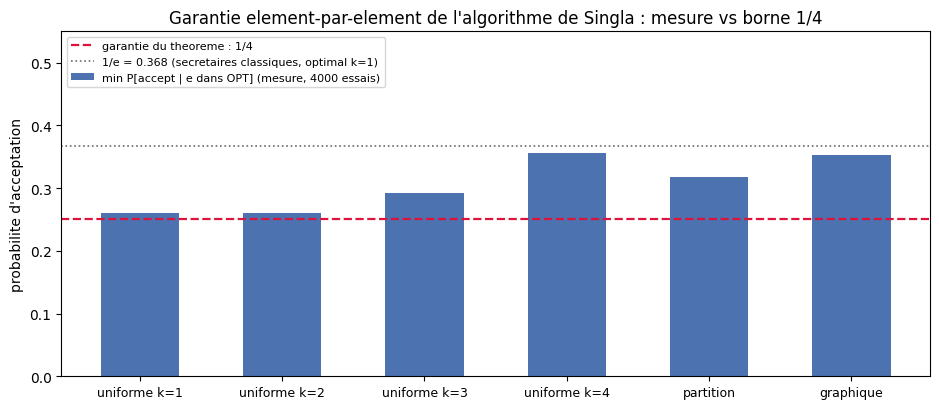

In [6]:
fig, ax = plt.subplots(figsize=(9.5, 4.2))
noms = [nom for nom, _ in INSTANCES]
lows = [min(resultats[n][1].values()) for n in noms]
x = range(len(noms))
ax.bar(x, lows, 0.55, color="#4C72B0", label="min P[accept | e dans OPT] (mesure, 4000 essais)")
ax.axhline(0.25, color="crimson", ls="--", lw=1.6, label="garantie du theoreme : 1/4")
ax.axhline(1 / 2.71828, color="dimgray", ls=":", lw=1.2, label="1/e = 0.368 (secretaires classiques, optimal k=1)")
ax.set_xticks(list(x))
ax.set_xticklabels(noms, fontsize=9)
ax.set_ylim(0, 0.55)
ax.set_ylabel("probabilite d'acceptation")
ax.set_title("Garantie element-par-element de l'algorithme de Singla : mesure vs borne 1/4")
ax.legend(fontsize=8, loc="upper left")
plt.tight_layout()
plt.show()

**Lecture** : la borne 1/4 (ligne rouge) n'est jamais franchie ; les points les plus bas
sont les matroïdes uniformes de rang 1 et 2 (0,261 et 0,260) — les cas les plus contraints,
au plus près de la borne : sur ces instances, la garantie est **serrée**. Deux régularités
lisibles :

1. **la fréquence monte avec le rang** (0,26 → 0,29 → 0,36 de k=1 à k=4) : plus il y a de
   places, moins le conflit entre éléments de l'OPT est dur — l'inverse de l'intuition
   k-server du notebook précédent, où chaque serveur supplémentaire ajoutait de la masse
   à déplacer ;
2. **la structure compte** : dans le partition, l'élément de la classe à quota 1 plafonne
   (0,32) pendant que les autres montent à 0,44-0,45 — le goulot est la contrainte, pas la
   valeur.

## 6. Le ratio en espérance : E[ALG]/OPT ≈ 0,44 pour une garantie 0,25

La garantie élément-par-élément implique (par linéarité de l'espérance) E[ALG] ≥ OPT/4.
Les ratios mesurés vivent entre **0,42 et 0,45** (moyenne 0,439) : environ 1,75 × la
garantie. Le même écart « borne pire-cas vs conduite quotidienne » que pour WFA en rl_17 —
deux familles d'algorithmes online, deux fois le même motif : la garantie est une ceinture
de sécurité, pas une prédiction.

In [7]:
print(f"{'instance':14s} {'E[ALG]/OPT':>10s} {'garantie':>9s}")
for nom, _ in INSTANCES:
    _, _, val_moy = resultats[nom]
    v_opt = sum(VALEURS[e] for e in resultats[nom][0])
    print(f"{nom:14s} {val_moy / v_opt:10.2f} {0.25:>9.2f}")
print("\nMoyenne des 6 ratios :", round(sum(resultats[n][2] / sum(VALEURS[e] for e in resultats[n][0]) for n, _ in INSTANCES) / 6, 3))

instance       E[ALG]/OPT  garantie
uniforme k=1         0.45      0.25
uniforme k=2         0.42      0.25
uniforme k=3         0.42      0.25
uniforme k=4         0.45      0.25
partition            0.45      0.25
graphique            0.45      0.25

Moyenne des 6 ratios : 0.439


## 7. Le prix de l'universalité : le seuil 1/e contre 1/4

Sur le matroïde **uniforme de rang 1** (= le problème des secrétaires original),
l'algorithme **dédié** est la stratégie du seuil : observer les n/e premiers candidats,
puis accepter le premier qui bat le maximum observé. En petit n, la probabilité exacte de
recruter le meilleur vaut `(k/n) Σ_{i>k} 1/(i-1)` avec k = ⌈n/e⌉ observés — pour n = 8,
k = 3 : **≈ 0,410** (mesuré ci-dessous : 0,400). La constante **1/e ≈ 0,368** est la
*limite asymptotique* quand n → ∞ (et la stratégie est optimale dans les deux régimes) —
un rappel utile : les constantes élégantes des théorèmes sont souvent des limites, pas
des valeurs de petit banc.

L'algorithme de Singla, lui, est **universel** : le même code, aveugle au matroïde (il n'a
que l'oracle), obtient 0,26 sur ce même cas. Le prix de l'universalité sur cette instance :
**0,41 → 0,26** (et à la limite : 1/e → 1/4) quand on abandonne la connaissance de la
structure pour ne garder qu'un oracle. Cette transition est exactement le contenu de la
conjecture : un algorithme unique qui tient sur **tout** matroïde.

In [8]:
def secretaires_classique(valeurs, rng):
    """Strategie du seuil 1/e : observer n/e candidats, puis prendre le premier qui bat
    le max observe. Retourne l'element choisi (ou None)."""
    n = len(valeurs)
    n_obs = max(1, round(n / 2.71828))
    ordre = list(range(n))
    rng.shuffle(ordre)
    seuil = max(valeurs[e] for e in ordre[:n_obs])
    for e in ordre[n_obs:]:
        if valeurs[e] > seuil:
            return e
    return None

rng_cmp = random.Random(11)
T = 4000
succes_classique = 0
for _ in range(T):
    if secretaires_classique(VALEURS, rng_cmp) == 0:   # 0 = l'element de valeur 5.0
        succes_classique += 1
print(f"Secretaire classique (seuil n/e), rang 1, n=8 : P[recruter le meilleur] = {succes_classique / T:.3f}"
      f"  [formule exacte n=8 : 0.410 ; limite asymptotique 1/e = {1 / 2.71828:.3f}]")
print(f"Algorithme de Singla, meme instance           : P[accepter le meilleur] = {resultats['uniforme k=1'][1][0]:.3f}"
      f"  [garantie 1/4 = 0.250]")

Secretaire classique (seuil n/e), rang 1, n=8 : P[recruter le meilleur] = 0.400  [formule exacte n=8 : 0.410 ; limite asymptotique 1/e = 0.368]
Algorithme de Singla, meme instance           : P[accepter le meilleur] = 0.261  [garantie 1/4 = 0.250]


## 8. Ce que ce notebook a mesuré — et ce qu'il n'a pas prouvé

| Affirmation | Statut | Preuve dans ce notebook |
|---|---|---|
| P[accept \| e ∈ OPT] ≥ 1/4 sur les instances testées | **mesuré** | §5 : min 0,26 sur 6 instances × 4 000 essais |
| la borne est serrée sur le rang 1 | **mesuré** | §5 : 0,26 vs 0,25 sur uniforme k=1 |
| la garantie sert de test d'implémentation | **vécu** | §5 : notre bug donnait 0,119 — détecté par le banc |
| E[ALG]/OPT ≈ 0,44 (0,42-0,45) | **mesuré** | §6 |
| 1/e optimal pour le secrétaire classique | **cité** | Lindley 1961, Dynkin 1963 |
| ≥ 1/4 sur **tout** matroïde, ne connaissant que n + oracle | **cité, non prouvé** | preprint arXiv 2609.14555 (13/09/2026, **non relu**) |
| variante ≈ 3,16-compétitive | **annoncé, non vérifié** | le papier lui-même la qualifie d'unverified |

Limites du banc : n = 8 éléments (l'échantillon Bin(n,1/2) est petit), 3 familles de
matroïdes sur l'infinité existante, 4 000 essais (bruit ± 0,008). Le pire cas théorique —
le matroïde qui force exactement 1/4 — est construit par la preuve, pas par notre
échantillonnage ; rien ici ne distingue « borne juste » de « borne conservatrice »,
seulement « borne jamais violée ».


## 9. Exercices

Trois exercices, du plus guidé au plus ouvert. Rappel C.1 : les stubs ne lèvent jamais
d'erreur — le notebook s'exécute de bout en bout non complété.

### Exercice 1 — Le goulot de la partition

Dans le partition de §2, l'élément de la classe 0 (quota 1) plafonne à ≈ 0,32. Faites
varier le quota de cette classe de 1 à 3 (les autres inchangés) et mesurez le minimum des
fréquences à chaque fois. Question : le goulot suit-il le quota (l'élément contraint
décolle-t-il vers les 0,44 des éléments libres), ou reste-t-il collé à la borne ?

*Indices : (1) réutilisez `banc_garantie` avec un `partition_oracle` à quotas modifiés ;
(2) un essai par quota suffit (4 000 exécutions) ; (3) représentez min P[accept] vs quota.*

In [9]:
def effet_quota(quotas_classe0=(1, 2, 3), n_essais=4000):
    """Pour chaque quota de la classe 0 : le min des P[accept | e dans OPT].

    Retour : {quota: min_freq}.
    """
    # TODO etudiant
    return None

print("Exercice a completer")

Exercice a completer


### Exercice 2 — Approcher la borne sans la franchir

La mesure du §5 s'arrête à 0,26. Construisez une instance (valeurs et matroïde de votre
choix parmi les trois familles, n ≤ 10) dont le minimum mesuré soit **le plus bas possible
sans passer sous 0,25**. Deux pistes à explorer : des valeurs très serrées (l'ordre
glouton devient instable) et des contraintes fortes sur les meilleurs éléments. Que
suggère votre meilleur « presque 1/4 » sur la question « la borne est-elle atteinte » ?

*Indices : (1) partez de l'instance témoin et resserrez les écarts ; (2) `banc_garantie`
retourne les fréquences par élément — regardez toujours le min ; (3) attention au bruit :
4 000 essais = ±0,008, ne concluez pas sur 0,249.*

In [10]:
def instance_presque_un_quart():
    """Construit (valeurs, oracle) d'une instance ou min P[accept|e dans OPT] est minimal.

    Retour : (valeurs, ind) utilisables par banc_garantie.
    """
    # TODO etudiant
    return None

print("Exercice a completer")

Exercice a completer


### Exercice 3 — Le secrétaire k=2 dédié

Généralisez la stratégie du seuil au matroïde uniforme de rang 2 : observer n/e candidats,
puis accepter les candidats qui battent le max observé **jusqu'à avoir 2 éléments**. Mesurez
P[les DEUX éléments de l'OPT sont acceptés] et comparez au carré des fréquences de Singla
sur k=2 (§5 : ≈ 0,26² ≈ 0,07 pour l'intersection — à recalculer proprement depuis les
fréquences individuelles). La stratégie dédiée bat-elle l'universelle sur l'événement
« tout l'OPT recruté » ?

*Indices : (1) le classique s'arrête au premier succès — ici il faut une liste d'acceptés ;
(2) que faire si le seuil ne laisse passer que 1 candidat après n/e ? Comparez deux
politiques de rattrapage (prendre le dernier, prendre les 2 derniers) ; (3) mesurez
l'intersection exacte avec un compteur sur les exécutions de Singla.*

In [11]:
def secretaires_k2(valeurs, rng, rattrapage="dernier"):
    """Seuil 1/e generalise au rang 2. Retourne l'ensemble accepte (0 a 2 elements).

    rattrapage : politique quand moins de 2 candidats battent le seuil
    ("dernier" ou "deux_derniers").
    """
    # TODO etudiant
    return None

print("Exercice a completer")

Exercice a completer


## 10. Conclusion

- Le **secrétaire matroïdal** étend l'arrêt optimal aux contraintes d'indépendance ;
  trois familles jouets (uniforme, partition, graphique) se réduit à un oracle de
  quelques lignes.
- L'algorithme de Singla est **ordinal et économe en information** : n, un oracle, un
  échantillon binomial, un glouton des deux côtés — aucune distribution, aucun seuil.
- Mesuré : la garantie 1/4 n'est jamais violée, elle est **serrée sur les rangs 1-2**
  (0,261 et 0,260), la fréquence monte avec le rang et la place libre ; le ratio en
  espérance vit à ≈ 0,44 ; le prix de l'universalité est la transition 0,41 → 0,26 sur le
  cas classique n=8 (limite 1/e → 1/4).
- La garantie, utilisée comme test exécutable, a attrapé notre bug d'implémentation
  (0,119 mesuré) avant toute relecture — c'est peut-être la leçon la plus transférable.

**Pour aller plus loin** : rl_17 (k-server, l'autre conjecture tombée à 24 h d'écart) ;
le k-secretary de Kleinberg (2005) ; les algorithmes par classe de matroïdes
(graphique, laminar) qui dominaient avant le résultat général ; la version
**prophet inequality** (le même papier annonce 8-compétitif single-sample).

## Références

- Singla — *The Matroid Secretary Conjecture is True*, arXiv 2609.14555 (soumis 13/09/2026,
  preprint non relu).
- Babaioff, Immorlica, Kleinberg — *Matroids, secretary problems, and online mechanisms*
  (2007), la conjecture originelle.
- Lindley (1961), Dynkin (1963) — le problème des secrétaires et l'optimalité de 1/e.
- Kleinberg — *A multiple-choice secretary algorithm with applications to online auctions*
  (2005), k-secretary.
- Coester, Koutsoupias, Zbysiński — arXiv 2609.15979, l'autre conjecture (cf. rl_17).

---
*Notebook RL 18 — deuxième distillation d'un preprint de 72 h : la garantie d'un théorème
comme banc de mesure et test d'implémentation, sans en démontrer la preuve.*
